Copyright Hewlett Packard Enterprise Development LP.

# ORNL Telemetry Data Across All Caps using Arkouda

This is an attempt to transliterate the code in Data_across_All_Caps.ipynb that uses pandas into arkouda.

In [10]:
import arkouda as ak
import pandas as pd
ak.connect("x1003c6s5b1n0")

connected to arkouda server tcp://*:5555


In [11]:
dir = "/lus/scratch/khandeka/hpegithub/ORNL-telemetry-analysis/parquet-traces-for-LSMS-application/"

power_cap200 = "paper_lsms_scorep_papi_wombat_grace_hopper_plugins_production_200_16_events.parquet"
power_cap300 = "paper_lsms_scorep_papi_wombat_grace_hopper_plugins_production_300_16_events.parquet"
power_cap400 = "paper_lsms_scorep_papi_wombat_grace_hopper_plugins_production_400_16_events.parquet"
power_cap500 = "paper_lsms_scorep_papi_wombat_grace_hopper_plugins_production_500_16_events.parquet"
power_cap600 = "paper_lsms_scorep_papi_wombat_grace_hopper_plugins_production_600_16_events.parquet"
power_cap700 = "paper_lsms_scorep_papi_wombat_grace_hopper_plugins_production_700_16_events.parquet"
power_cap800 = "paper_lsms_scorep_papi_wombat_grace_hopper_plugins_production_800_16_events.parquet"
power_cap900 = "paper_lsms_scorep_papi_wombat_grace_hopper_plugins_production_900_16_events.parquet"
power_cap1000 = "paper_lsms_scorep_papi_wombat_grace_hopper_plugins_production_1000_16_events.parquet"

# List of power cap files
# power_caps = [power_cap200, power_cap300, power_cap400, power_cap500, power_cap600, power_cap700, power_cap800, power_cap900, power_cap1000]
power_caps = [power_cap1000]

power_cap_names = [name.split('_')[-3] for name in power_caps[::-1]]
print(power_cap_names)  # Output: ['800', '900', '1000']

['1000']


In [12]:
def read_parquet_and_drop_columns(file_path):
    ak_df = ak.read_parquet(file_path)
    # Drop the columns we don't need
    keys_to_keep = ['time', 'metric', 'values', 'region', 'location', 'event']
    ak_df = {key: ak_df[key] for key in keys_to_keep}
    ak_df = ak.DataFrame(ak_df)
    return ak_df

In [13]:
def preprocess_power_data(df):
    df = df[df["values"] != "nan"]
    df['values'] = df['values'].strip('[]').astype(ak.float64) / 1000 # convert miliwatts to watts
    return df

def find_leave_events(df):
    leave_events = df[df["event"] == "Leave"]
    leave_events = leave_events.sort_values("time")
    return leave_events

#### Note on the difference in approach when using Arkouda
Iterating directly over a DataFrame with `for x in df` is not recommended. Doing so is discouraged because it requires transferring all array data from the arkouda server to the Python client since there is almost always a more array-oriented way to express an iterator-based computation.

In [ ]:
import arkouda.array_api as xp
import numpy as np
import time as time

def getInclusiveEnergy(df, df_power):
    df_power = preprocess_power_data(df_power)
    start_time = time.time()
    enter_events = df[df['event'] == 'Enter']
    leave_events = find_leave_events(df)

    leave_times = leave_events['time']
    leave_regions = leave_events['region']

    enter_times = enter_events["time"]
    enter_regions = enter_events["region"]

    leave_indices = xp.searchsorted(xp.asarray(leave_times), xp.asarray(enter_times), side="left") # Bug in searchsorted. Meaning of side="left" and side="right" is swapped

    leave_indices = leave_indices._array

    valid_indices = (leave_indices < len(leave_times)) & (leave_regions[leave_indices] == enter_regions)

    valid_enter_times = enter_times[valid_indices]
    valid_leave_times = leave_times[valid_indices]
    valid_regions     = enter_regions[valid_indices]

    durations = valid_leave_times - valid_enter_times

    # Create an Arkouda DataFrame
    # region_times_df = ak.DataFrame({
    #     'region': valid_regions,
    #     'duration': durations
    # })

    # Group by 'region' and sum the 'duration'
    # region_times = region_times_df.groupby('region').sum("duration")

    # Sorted dict of region times is not used, no need to create it

    mid_time = time.time()
    runtime = mid_time - start_time
    # print(f"Runtime till region times: {runtime:.4f} seconds")


    # Vectorized energy calculation
    power_data_indices = xp.searchsorted(xp.asarray(df_power['time']), xp.asarray(valid_enter_times), side="right") # Bug in searchsorted. Meaning of side="left" and side="right" is swapped
    power_data_indices = xp.where(power_data_indices <= 0, len(df_power['time']) - 1 - power_data_indices, power_data_indices) # Indices less than 0 wrap around automatically, this seems to be technically incorrect, is a bug?
    power_data_indices = power_data_indices._array
    last_tracked_powers = df_power['values'][power_data_indices]
    last_tracked_energies = last_tracked_powers * durations

    runtime = time.time() - mid_time
    # print(f"Runtime for last Tracked Energies: {runtime:.4f} seconds")
    mid_time = time.time()

    # Create a mask to filter out the power data for each region
    # This is a 2D mask, where each row corresponds to a region and each column corresponds to a power data point
    # Calculating this is also slow in Arkouda, needs investigation
    energy_mask = (df_power['time'] >= valid_enter_times[:, None]) & (df_power['time'] <= valid_leave_times[:, None])
    power_data_not_empty = ak.any(energy_mask, axis=1)

    runtime = time.time() - mid_time
    # print(f"Runtime for energy mask: {runtime:.4f} seconds")
    mid_time = time.time()


    energy_values = ak.where(energy_mask, df_power['values'][:, None], 0)
    # energy_times = ak.where(energy_mask, df_power['time'][:, None], df_power['time'][:, None])
    energy_times = df_power['time']

    runtime = time.time() - mid_time
    # print(f"Runtime for energy df slices: {runtime:.4f} seconds")
    mid_time = time.time()

    energies = xp.trapz(xp.asarray(energy_values), xp.asarray(energy_times), axis=1)._array
    energies = ak.where(power_data_not_empty, energies, last_tracked_energies)

    runtime = time.time() - mid_time
    # print(f"Runtime for trapz vectorized: {runtime:.4f} seconds")
    mid_time = time.time()

    # This is really inefficient
    # Took more than 30m to run?
    # This is wayyy more than pandas, why? It's the same sized loop. Are the opeerations in here that slow?
    # energies = ak.zeros(energy_mask.shape[0], dtype=ak.float64)
    # for i in range(energy_mask.shape[0]):
    #     power_data = df_power[energy_mask[i, :]]
    #     energies[i] = xp.trapz(xp.asarray(power_data['values']), xp.asarray(power_data['time']))._array if not power_data.empty else last_tracked_energies[i]

    # runtime = time.time() - mid_time
    # print(f"Runtime for trapz: {runtime:.4f} seconds")
    # mid_time = time.time()

    energy_data = {
        'region': valid_regions,
        'energy': last_tracked_energies, #FIXME change to energies
        'duration': durations
    }

    df_energies = ak.DataFrame(energy_data)
    region_energy_groupby = df_energies.GroupBy('region', use_series=True)
    # Sum both 'energy' and 'duration' per region
    df_energies = region_energy_groupby.sum(['energy', 'duration']).sort_values('energy', ascending=False)
    df_energies = df_energies[df_energies['energy'] > 1.0]

    end_time = time.time()
    runtime = end_time - start_time
    print(f"Runtime: {runtime:.2f} seconds")


    # There might be a bug here
    df_energies_pandas = df_energies.to_pandas(retain_index=True)
    # print(df_energies_pandas)

    # Output the regions and their total energies
    print("\n=== Total Energy per Region ===")
    for _, row in df_energies_pandas.iterrows():
        region = row.name
        energy = row['energy']
        total_time = row['duration']
        print(f"Region: {region}, Total Energy: {energy:.2f} J, Total Time: {total_time:.2f} s")

    return df_energies_pandas.head(8)


In [15]:
def get_avg_power(df_energies: pd.DataFrame):
    # Add the avg power column to the same DataFrame
    # Nice for a demo, but you would just do the division here instead of using assign
    # df_energies.assign(avg_power=lambda x: (x['energy']*x['times']))

    return {region: avg_power for region, avg_power in zip(df_energies.index, df_energies['energy'].values/df_energies['duration'].values)}


In [16]:
def get_speedup_perf_drop(df_energies, baseline):
    speedup_energy = {}
    performance_drop = {}
    energy_saved = {}

    for _, row in df_energies.iterrows():
        region = row.name
        energy = row['energy']
        runtime = row['duration']
        baseline_runtime = baseline.loc[region, 'duration']
        baseline_energy = baseline.loc[region, 'energy']

        if baseline_runtime and baseline_energy and runtime and energy:
            speedup = (baseline_runtime * baseline_energy) / (runtime * energy)
            energy_saved[region] = 100 * (energy - baseline_energy) / baseline_energy if energy != 0 else None
            performance_drop[region] = 100 * (runtime - baseline_runtime) / baseline_runtime if runtime != 0 else None
        else:
            speedup = None
            energy_saved[region] = None
            performance_drop[region] = None

        speedup_energy[region] = speedup

    return energy_saved, performance_drop, speedup_energy


In [17]:
avg_power_data = {}
energy_saved_data = {}
performance_drop_data = {}
speedup_energy_data = {}

for cap in power_caps[::-1]:
    df_events = read_parquet_and_drop_columns(dir+cap)

    df_events["time"] = df_events["time"].astype(ak.int64) # Convert time to seconds
    df_events["time"] = (df_events['time'] - df_events['time'][0]) / 1000000000

    df_gpupower = df_events[df_events["metric"] == "MetricInstance [21]: 'metric_class': MetricClass [20], 'recorder': Location [47244640256] '', 'metric_scope': MetricScope.SYSTEM_TREE_NODE, 'scope': SystemTreeNode [1] 'wombat35'"].copy()

    regions = df_events[df_events["region"] != "nan"]  # Filter out rows where region is NaN
    df_gpuevents = regions[regions["location"] == "CUDA[0:7]"].copy()
    # df_gpuevents = df_gpuevents[df_gpuevents["region"]!= "nan"].copy()

    df_energies = getInclusiveEnergy(df_gpuevents, df_gpupower)

    if cap == power_cap1000:
        baseline = df_energies

    # use arrays and dataframes
    avg_power = get_avg_power(df_energies)
    energy_saved, performance_drop, speedup_energy  = get_speedup_perf_drop(df_energies, baseline)



Runtime: 186.29 seconds

=== Total Energy per Region ===
Region: sm90_xmma_gemm_cf64cf64_f64f64_cf64_nn_n_tilesize64x64x32_stage3_warpsize4x2x1_tensor16x8x16_execute_kernel__5x_cublas, Total Energy: 43029.30 J, Total Time: 77.79 s
Region: buildKKRMatrixMultiplyKernelCuda, Total Energy: 20557.68 J, Total Time: 34.91 s
Region: COMPUTE IDLE, Total Energy: 5194.46 J, Total Time: 8.89 s
Region: sm90_xmma_gemm_cf64cf64_f64f64_cf64_nn_n_tilesize32x32x32_stage3_warpsize2x2x1_tensor16x8x16_execute_kernel__5x_cublas, Total Energy: 4655.86 J, Total Time: 8.03 s
Region: getrf_pivot<getrf_params_<double2, 512, 2, 512, 64, 16> >, Total Energy: 2329.85 J, Total Time: 4.07 s
Region: getrf_pivot<getrf_params_<double2, 512, 2, 512, 32, 32> >, Total Energy: 2227.55 J, Total Time: 4.07 s
Region: trsm_left_kernel<int, double2, 256, 4, true, false, false, false, true>, Total Energy: 2050.86 J, Total Time: 3.57 s
Region: getrf_pivot<getrf_params_<double2, 512, 2, 512, 64, 8> >, Total Energy: 1094.86 J, Total

The performance here is weird.
1. `trapz` is slow, we need to fix that no matter what.

    `diff` is the slow part. Took 4 minutes and 30 seconds on a single locale in vectorized approach. Gotta make it go faster. Much faster.

    Parallelize?

    ```
    Runtime till sorted Regions: 2.7475 seconds
    Runtime for last Tracked Energies: 0.0986 seconds
    Runtime for energy mask: 24.2927 seconds
    Runtime for energy df slices: 30.1435 seconds
    Runtime for trapz vectorized: 364.7088 seconds
    ```

    After making diff more parallel:

    ```
    
    ```

2. The broadcast operations (which use 2D arrays in Arkouda) are also slow, and they get slower when increasing numlocales.
    Ex: with one locale, we have:
    ```
    Runtime till last Tracked Energies: 2.4532 seconds
    Runtime till energy mask: 25.7048 seconds
    Runtime till energy df slices: 56.4390 seconds
    ```
    But upping that to just two locales (same amount of data actually being worked on):
    ```
    Runtime till last Tracked Energies: 4.6643 seconds
    Runtime till energy mask: 326.5029 seconds
    Runtime till energy df slices: 348.3798 seconds
    ```
    Which is crazy!!
    In my observation of this run, there a `broadcast` call which takes the most amount of time, `binopvv` is pretty fast.




Plotting code would be the same

/tmp/ipykernel_507402/3495046069.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="best")


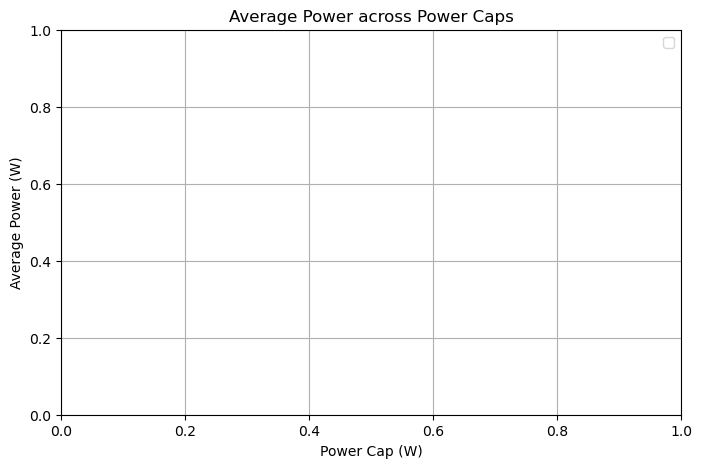

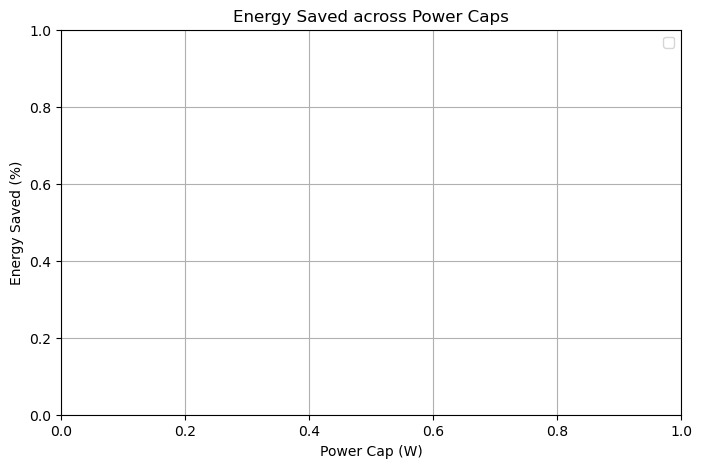

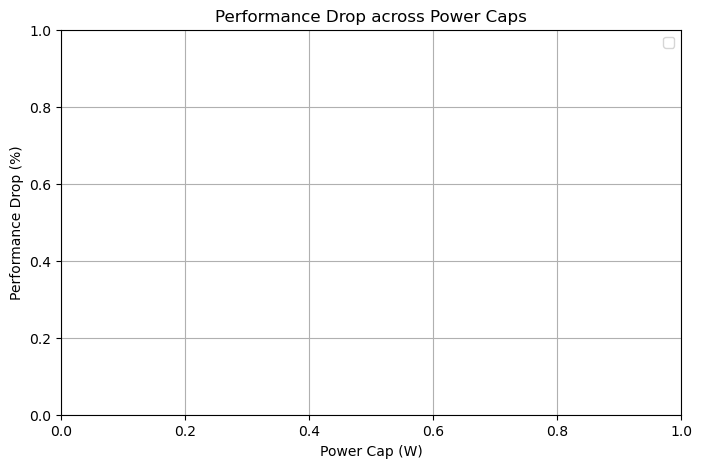

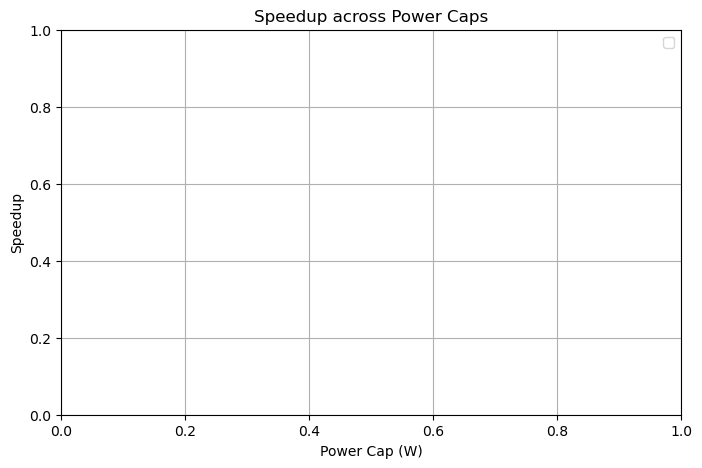

In [18]:
import matplotlib.pyplot as plt

# Plotting function
def plot_metric_across_power_caps(data, title, ylabel):
    plt.figure(figsize=(8, 5))
    for region, values in data.items():
        if region == "COMPUTE IDLE":
            continue
        # Shorten the region name for the legend
        short_region = region[:15] + "..." if len(region) > 15 else region
        plt.plot(power_cap_names, values, marker='o', label=short_region)
    plt.xlabel("Power Cap (W)")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

# Plot each metric
plot_metric_across_power_caps(avg_power_data, "Average Power across Power Caps", "Average Power (W)")
plot_metric_across_power_caps(energy_saved_data, "Energy Saved across Power Caps", "Energy Saved (%)")
plot_metric_across_power_caps(performance_drop_data, "Performance Drop across Power Caps", "Performance Drop (%)")
plot_metric_across_power_caps(speedup_energy_data, "Speedup across Power Caps", "Speedup")